Run NER Codebook 

Author: Charlotte Bez

Last Updates: End of March 2026

In [18]:
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns
import unicodedata
import matplotlib.cm as cm
import numpy as np
import warnings

### Load the codebook

In [19]:
# Open Codebook
codebook = pd.read_excel("NER_Codebook_1615.xlsx")
codebook['Sub_category'] = codebook['Sub_category'].replace("International Organisation", "International Organization")

print("Codebook columns:", codebook.columns.tolist())
print("Codebook number of rows:", len(codebook))

# Check if all rows have an entry for the second column
second_col = codebook.columns[1]
missing = codebook[second_col].isna() | (codebook[second_col].astype(str).str.strip() == "")
print("Second column:", second_col)
if missing.any():
    print(str(missing.sum()) + " row(s) missing a value:")
    print(codebook[missing][["Entities_filtered", second_col]].to_string())
else:
    print("All rows have an entry.")

# Check for duplicates in Entities_filtered
duplicates = codebook[codebook.duplicated(subset='Entities_filtered', keep=False)].sort_values('Entities_filtered')
if duplicates.empty:
    print("No duplicates found in Entities_filtered.")
else:
    print("Duplicates found (" + str(len(duplicates)) + " rows, " + str(duplicates['Entities_filtered'].nunique()) + " unique values):")
    print(duplicates[['Entities_filtered', 'Sub_category']].to_string(index=False))

Codebook columns: ['Entities_filtered', 'Sub_category', 'Flag_Individuals_Codebook', 'Unnamed: 3']
Codebook number of rows: 1560
Second column: Sub_category
All rows have an entry.
No duplicates found in Entities_filtered.


### Load dataset A

In [3]:
# List files in current directory
print("Files in folder:", os.listdir("."))

# Open Dataset A
df_a = pd.read_excel("Final_DatasetA_102725.xlsx")

print("Dataset A columns:", df_a.columns.tolist())
print("Dataset A number of rows:", len(df_a))

# Check if all rows have an entry for the second column
second_col = df_a.columns[1]
missing = df_a[second_col].isna() | (df_a[second_col].astype(str).str.strip() == "")
print("Second column:", second_col)
if missing.any():
    print(str(missing.sum()) + " row(s) missing a value:")
    print(df_a[missing][[second_col]].to_string())
else:
    print("All rows have an entry.")

cols_to_clear = [
    'Academia', 'Consultancy', 'Courts', 'Energy Industry', 'Government Agency',
    'International Climate Governance', 'International Organization', 'Journalist',
    'Keyword Climate/Energy', 'Keyword Greenwashing', 'Legal Professionals',
    'Legislation', 'Litigation', 'Lobby', 'NGO/Thinktank/Foundation', 'News Outlet',
    'Other Industry', 'PR Company', 'Politician'
]

df_a[cols_to_clear] = ""

Files in folder: ['.claude', '.git', '.ipynb_checkpoints', 'archive', 'combined_table_ab.csv', 'Creation_NER_Codebook.html', 'Creation_NER_Codebook.ipynb', 'Creation_NER_Codebook.py', 'df_a_airtable.xlsx', 'df_b_airtable.xlsx', 'Final_DatasetA_102725.xlsx', 'Final_DatasetB_031926.xlsx', 'Final_DatasetB_102725.xlsx', 'Graph_Top_Entities.ipynb', 'Hive_Plot_Most_Frequent_Entities.png', 'ner_acronyms_v2_cleaned.xlsx', 'NER_Codebook_1615.xlsx', 'Preparation_LexisNexis_Entities.html', 'Run_NER_Codebook.html', 'Run_NER_Codebook.ipynb', 'Run_NER_Codebook.py', 'Run_NER_Codebook_archived.ipynb']
Dataset A columns: ['Document ID', 'Organization', 'Earliest Date', 'Latest Date', 'Document Type Category', 'File Content', 'Redaction Amount', 'redaction_percentage_1', 'redaction_percentage_2', 'individuals_involved', 'individuals_mentioned', 'organizations_involved', 'organizations_mentioned', 'Academia', 'Consultancy', 'Courts', 'Energy Industry', 'Government Agency', 'International Climate Governan

In [4]:
# Normalize Sub_category names to match df column names exactly.
SUBCATEGORY_MAP = {
    'International Organisation': 'International Organization',
    'Journalism, Editorial':      'Journalist',
    'Media':                      'News Outlet',
}

# Build entity list: split semicolons in both Entities_filtered and Sub_category.
# e.g. "Academia; Consultancy" -> entity maps to both categories.
# Sort longest-first so longer matches take priority.
all_entity_cat = {}     # lowercase key -> set of sub_categories
all_entity_display = {} # lowercase key -> original-cased string from codebook
for _, row in codebook.iterrows():
    sub_cats_raw = str(row['Sub_category']).strip()
    raw = str(row['Entities_filtered']).strip()
    if not raw or raw == 'nan' or sub_cats_raw == 'nan':
        continue
    aliases_original = [a.strip() for a in raw.split(';') if a.strip()]
    sub_cats = {SUBCATEGORY_MAP.get(s.strip(), s.strip())
                for s in sub_cats_raw.split(';') if s.strip()}
    for alias_orig in aliases_original:
        alias = alias_orig.lower()
        if alias not in all_entity_cat:
            all_entity_cat[alias] = set()
        all_entity_cat[alias].update(sub_cats)
        all_entity_display[alias] = alias_orig

# Extra entities not in the codebook that should be matched to a specific category.
EXTRA_ENTITIES = {
    'scientific journal':    'Academia',
    'academic journal':      'Academia',
    'peer-reviewed journal': 'Academia',
}
for phrase, cat in EXTRA_ENTITIES.items():
    all_entity_cat[phrase.lower()] = {cat}
    all_entity_display[phrase.lower()] = phrase

# Known multi-word contexts where a sub-entity should NOT match.
EXCLUSION_PHRASES = [
    'electoral college',
    'british columbia',
    'district of columbia',
    'journal',
    'college',
    'act',
    'hearing',
    # Berkeley false positives
    'berkeley county',
    'berkeley pit',
    'lord berkeley land trust',
    # Columbia false positives
    'columbia energy exchange',
    'columbia call',
    # Generic words misclassified as Academia
    'dean',
    'alumni',
    'campus',
    # Oxford false positive
    'drive oxford',
]
EXCLUDE = '__exclude__'
for phrase in EXCLUSION_PHRASES:
    all_entity_cat[phrase] = {EXCLUDE}

# All-caps acronyms must match case-sensitively (e.g. SAFE != safe, EPA != epa)
all_entity_caps_sensitive = set()
for alias_lower, alias_orig in all_entity_display.items():
    letters = [c for c in alias_orig if c.isalpha()]
    if letters and all(c.isupper() for c in letters):
        all_entity_caps_sensitive.add(alias_lower)

# Sort by length descending so longer/more-specific entities are matched first
all_entities_sorted = sorted(all_entity_cat.keys(), key=len, reverse=True)

def find_all_matches(text):
    norm_text = re.sub(r'\s+', ' ', str(text).lower())
    orig_text = re.sub(r'\s+', ' ', str(text))  # original case for caps-sensitive matching
    matched_positions = set()
    category_matches = defaultdict(list)

    for entity_str in all_entities_sorted:
        escaped = re.escape(entity_str)
        if entity_str in all_entity_caps_sensitive:
            # All-caps acronym: match the original capitalised form case-sensitively
            caps_form = all_entity_display[entity_str]
            pattern = r'\b' + re.escape(caps_form) + r"(?:'s|s')?\b"
            search_text = orig_text
        else:
            pattern = r'\b' + escaped + r"(?:'s|s')?\b"
            search_text = norm_text
        for m in re.finditer(pattern, search_text):
            start, end = m.span()
            span_positions = set(range(start, end))
            if not span_positions & matched_positions:
                matched_positions.update(span_positions)
                display = all_entity_display.get(entity_str, entity_str)
                for cat in all_entity_cat[entity_str]:
                    if cat != EXCLUDE and display not in category_matches[cat]:
                        category_matches[cat].append(display)

    return {cat: '; '.join(entities) for cat, entities in category_matches.items()}

# Populate Dataset A (all categories in one pass per row)
results_a = df_a['File Content'].apply(find_all_matches)
for category in cols_to_clear:
    if category in df_a.columns:
        df_a[category] = results_a.apply(lambda d: d.get(category, ''))

In [5]:
# List of the columns we populated
populated_cols = [col for col in df_a.columns if col in {cat for cats in all_entity_cat.values() for cat in cats} - {EXCLUDE}]

# Count number of matches per row (across populated columns)
df_a['num_entities_found'] = df_a[populated_cols].apply(lambda row: sum(bool(cell) for cell in row), axis=1)

# Descriptive stats
no_entities = (df_a['num_entities_found'] == 0).sum()
max_entities = df_a['num_entities_found'].max()
avg_entities = df_a['num_entities_found'].mean()

print("\nDescriptive stats:")
print(f"Rows with no entities found: {no_entities}")
print(f"Maximum number of categories with entities in a row: {max_entities}")
print(f"Average number of categories with entities per row: {avg_entities:.2f}")

entities_per_column = df_a[populated_cols].apply(lambda col: col.astype(bool).sum()).sort_values(ascending=False)

print("Number of rows with entities per category:\n")
print(entities_per_column)


Descriptive stats:
Rows with no entities found: 20
Maximum number of categories with entities in a row: 13
Average number of categories with entities per row: 3.95
Number of rows with entities per category:

Energy Industry                     185
Keyword Climate/Energy              136
Other Industry                       67
Litigation                           59
Lobby                                56
Government Agency                    52
Academia                             37
International Climate Governance     37
NGO/Thinktank/Foundation             36
Keyword Greenwashing                 36
News Outlet                          32
International Organization           30
Politician                           29
Legal Professionals                  26
Courts                               21
Consultancy                          13
Journalist                            5
PR Company                            4
dtype: int64


In [6]:
# Define umbrella categories and their subcategories
umbrella_categories = [
    "Government & Policy",
    "Advocacy & Research",
    "Industry & Business",
    "Judiciary",
    "Media",
    "Climate Keywords"
]

umbrella_mapping = {
    "Government & Policy": [
        "Government Agency", "Politician", "Legislation/Regulation",
        "International Organization", "International Climate Governance"
    ],
    "Advocacy & Research": ["Academia", "Lobby", "NGO/Thinktank/Foundation"],
    "Industry & Business": ["Energy Industry", "Other Industry", "Consultancy", "PR Company"],
    "Judiciary": ["Litigation", "Courts", "Legal Professionals"],
    "Media": ["News Outlet", "Journalist"],
    "Climate Keywords": ["Keyword Climate/Energy", "Keyword Greenwashing"]
}

# Specify desired row order including umbrella categories
row_order = [
    "Government & Policy",
    "Government Agency",
    "Politician",
    "Legislation/Regulation",
    "International Organization",
    "International Climate Governance",
    "Advocacy & Research",
    "Academia",
    "Lobby",
    "NGO/Thinktank/Foundation",
    "Industry & Business",
    "Energy Industry",
    "Other Industry",
    "Consultancy",
    "PR Company",
    "Judiciary",
    "Litigation",
    "Courts",
    "Legal Professionals",
    "Media",
    "News Outlet",
    "Journalist",
    "Climate Keywords",
    "Keyword Climate/Energy",
    "Keyword Greenwashing"
]

In [7]:
df_filtered = df_a[df_a['Organization'].str.strip().str.lower() != 'chamber']

entities_by_org = df_filtered.groupby('Organization')[populated_cols].apply(lambda df: df.astype(bool).sum())
entities_by_org_t = entities_by_org.T

# Start with only existing rows from your table
rows_present = [r for r in row_order if r in entities_by_org_t.index]
new_table = entities_by_org_t.loc[rows_present].copy()

# Explicitly add umbrella category rows with sum of their subcategories
for umbrella, subs in umbrella_mapping.items():
    subs_present = [s for s in subs if s in new_table.index]
    if subs_present:
        # Sum the subcategories
        new_table.loc[umbrella] = new_table.loc[subs_present].sum()

# Reorder again to match row_order (including newly added umbrella rows)
final_table = new_table.reindex(row_order)
#final_table = final_table.astype(int)
print("Prepared new table with umbrella categories summed:\n")
print(final_table)

Prepared new table with umbrella categories summed:

Organization                       API    BP  Chevron  Exxon  Shell
Government & Policy               43.0  25.0     38.0   19.0   23.0
Government Agency                 19.0  10.0     15.0    5.0    3.0
Politician                        12.0   7.0      3.0    2.0    5.0
Legislation/Regulation             NaN   NaN      NaN    NaN    NaN
International Organization         3.0   4.0     13.0    4.0    6.0
International Climate Governance   9.0   4.0      7.0    8.0    9.0
Advocacy & Research               28.0  35.0     22.0   14.0   30.0
Academia                           4.0  10.0     11.0    7.0    5.0
Lobby                             18.0  12.0      4.0    7.0   15.0
NGO/Thinktank/Foundation           6.0  13.0      7.0    0.0   10.0
Industry & Business               45.0  46.0     74.0   49.0   55.0
Energy Industry                   33.0  29.0     61.0   28.0   34.0
Other Industry                     6.0  15.0      6.0   20.0   

In [8]:
for idx, row in final_table.iterrows():
    # Escape & for LaTeX
    row_name = idx.replace("&", r"\&")
    
    # Wrap umbrella categories in \textbf{}
    if idx in umbrella_categories:
        row_name = r"\textbf{" + row_name + "}"
    
    # Join the values with ' & '
    counts = " & ".join(str(int(v)) if pd.notna(v) else "0" for v in row.values)
    
    # Print as LaTeX table row
    print(f"{row_name} & {counts} \\\\")

\textbf{Government \& Policy} & 43 & 25 & 38 & 19 & 23 \\
Government Agency & 19 & 10 & 15 & 5 & 3 \\
Politician & 12 & 7 & 3 & 2 & 5 \\
Legislation/Regulation & 0 & 0 & 0 & 0 & 0 \\
International Organization & 3 & 4 & 13 & 4 & 6 \\
International Climate Governance & 9 & 4 & 7 & 8 & 9 \\
\textbf{Advocacy \& Research} & 28 & 35 & 22 & 14 & 30 \\
Academia & 4 & 10 & 11 & 7 & 5 \\
Lobby & 18 & 12 & 4 & 7 & 15 \\
NGO/Thinktank/Foundation & 6 & 13 & 7 & 0 & 10 \\
\textbf{Industry \& Business} & 45 & 46 & 74 & 49 & 55 \\
Energy Industry & 33 & 29 & 61 & 28 & 34 \\
Other Industry & 6 & 15 & 6 & 20 & 20 \\
Consultancy & 5 & 1 & 7 & 0 & 0 \\
PR Company & 1 & 1 & 0 & 1 & 1 \\
\textbf{Judiciary} & 16 & 16 & 41 & 16 & 17 \\
Litigation & 10 & 10 & 19 & 11 & 9 \\
Courts & 2 & 3 & 6 & 2 & 8 \\
Legal Professionals & 4 & 3 & 16 & 3 & 0 \\
\textbf{Media} & 6 & 4 & 5 & 7 & 15 \\
News Outlet & 6 & 4 & 5 & 6 & 11 \\
Journalist & 0 & 0 & 0 & 1 & 4 \\
\textbf{Climate Keywords} & 40 & 33 & 38 & 26 & 35 \\
Ke

In [10]:
# put in memory for later use
dataset_a_table = final_table.iloc[:, :5].copy()
dataset_a_table = dataset_a_table.astype(int)
dataset_a_table.head()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

### Load dataset B

In [ ]:
df_b = pd.read_excel("Final_DatasetB_102725.xlsx")

# Print column names and data lengths
print("\nDataset B columns:", df_b.columns.tolist())
print("Dataset B number of rows:", len(df_b))

df_b[cols_to_clear] = ""


Dataset B columns: ['Document ID', 'Organization', 'Earliest Date', 'Latest Date', 'Document Type Category', 'FlagForReview', 'File Content', 'Redaction Amount', 'redaction_percentage_1', 'redaction_percentage_2', 'People', 'Academia', 'Consultancy', 'Courts', 'Energy Industry', 'Government Agency', 'International Climate Governance', 'International Organization', 'Journalist', 'Keyword Climate Environment', 'Keyword Obstructionism', 'Legal Professionals', 'Legislation', 'Litigation', 'Lobby', 'NGO/Thinktank/Foundation', 'News Outlet', 'Other Industry', 'PR Company', 'Politician', 'Advocacy_Research', 'Climate_Keywords', 'Government_Policy', 'Industry_Business', 'Judiciary', 'Media']
Dataset B number of rows: 4479


In [ ]:
# Quick test on 10 rows before the full 24-min run
# If this shows 0 matches, do NOT proceed â€” fix find_all_matches or codebook first.
sample = df_b['File Content'].head(10).apply(find_all_matches)
sample_counts = {cat: sum(1 for d in sample if cat in d) for cat in cols_to_clear}
sample_counts = {k: v for k, v in sorted(sample_counts.items(), key=lambda x: -x[1]) if v > 0}

print("=== Sample test (10 rows) ===")
if sample_counts:
    for cat, count in sample_counts.items():
        print(" ", cat, ":", count, "rows")
    print("OK â€” matching works. Safe to run the full population.")
else:
    print("WARNING: no matches in sample â€” do NOT run the full population.")

=== Sample test (10 rows) ===
  Energy Industry : 10 rows
  Legal Professionals : 7 rows
  Politician : 7 rows
  Government Agency : 5 rows
  Keyword Climate/Energy : 5 rows
  Legislation : 5 rows
  Litigation : 5 rows
  Lobby : 4 rows
  Consultancy : 3 rows
  Courts : 3 rows
  International Climate Governance : 3 rows
  NGO/Thinktank/Foundation : 3 rows
  News Outlet : 3 rows
  International Organization : 2 rows
  Keyword Greenwashing : 2 rows
  Other Industry : 2 rows
  PR Company : 2 rows
  Journalist : 1 rows
OK â€” matching works. Safe to run the full population.


takes approx. 17 - 37 minutes to run the code below.

In [ ]:
# Populate Dataset B (all categories in one pass per row, same logic as Dataset A)
results_b = df_b['File Content'].apply(find_all_matches)
for category in cols_to_clear:
    if category in df_b.columns:
        df_b[category] = results_b.apply(lambda d: d.get(category, ""))

In [ ]:
# List of the columns we populated
populated_cols = [col for col in df_b.columns if col in {cat for cats in all_entity_cat.values() for cat in cats} - {EXCLUDE}]

# Count number of matches per row (across populated columns)
df_b['num_entities_found'] = df_b[populated_cols].apply(lambda row: sum(bool(cell) for cell in row), axis=1)

# Descriptive stats
no_entities = (df_b['num_entities_found'] == 0).sum()
max_entities = df_b['num_entities_found'].max()
avg_entities = df_b['num_entities_found'].mean()

print("\nDescriptive stats:")
print(f"Rows with no entities found: {no_entities}")
print(f"Maximum number of categories with entities in a row: {max_entities}")
print(f"Average number of categories with entities per row: {avg_entities:.2f}")

entities_per_column = df_b[populated_cols].apply(lambda col: col.astype(bool).sum()).sort_values(ascending=False)

print("Number of rows with entities per category:\n")
print(entities_per_column)


Descriptive stats:
Rows with no entities found: 2867
Maximum number of categories with entities in a row: 16
Average number of categories with entities per row: 2.22
Number of rows with entities per category:

Energy Industry                     1397
Keyword Climate/Energy              1277
Other Industry                       789
Litigation                           778
Government Agency                    712
Politician                           699
Legislation                          671
Lobby                                581
News Outlet                          527
NGO/Thinktank/Foundation             460
International Climate Governance     390
Courts                               333
Keyword Greenwashing                 294
Legal Professionals                  282
International Organization           273
Academia                             222
Consultancy                          147
PR Company                            60
Journalist                            32
dtype: int

In [ ]:
df_filtered = df_b[df_b['Organization'].str.strip().str.lower() != 'chamber']

entities_by_org = df_filtered.groupby('Organization')[populated_cols].apply(lambda df: df.astype(bool).sum())
entities_by_org_t = entities_by_org.T

# Start with only existing rows from your table
rows_present = [r for r in row_order if r in entities_by_org_t.index]
new_table = entities_by_org_t.loc[rows_present].copy()

# Explicitly add umbrella category rows with sum of their subcategories
for umbrella, subs in umbrella_mapping.items():
    subs_present = [s for s in subs if s in new_table.index]
    if subs_present:
        # Sum the subcategories
        new_table.loc[umbrella] = new_table.loc[subs_present].sum()

# Reorder again to match row_order (including newly added umbrella rows)
final_table = new_table.reindex(row_order)
#final_table = final_table.astype(int)
print("Prepared new table with umbrella categories summed:\n")
print(final_table)

Prepared new table with umbrella categories summed:

Organization                      API    BP  Chevron  Exxon  Shell
Government & Policy               637  1812      143    100     51
Government Agency                 120   501       55     24     12
Politician                        185   465       22     18      9
Legislation                       162   452       33     15      9
International Organization         53   176       15     17     11
International Climate Governance  117   218       18     26     10
Advocacy & Research               177   928       43     63     49
Academia                            7   186        2     19      8
Lobby                             113   392       23     31     20
NGO/Thinktank/Foundation           57   350       18     13     21
Industry & Business               458  1641      113    116     63
Energy Industry                   307   897       79     74     39
Other Industry                     38   680       17     35     18
Consultan

In [ ]:
for idx, row in final_table.iterrows():
    # Escape & for LaTeX
    row_name = idx.replace("&", r"\&")
    
    # Wrap umbrella categories in \textbf{}
    if idx in umbrella_categories:
        row_name = r"\textbf{" + row_name + "}"
    
    # Join the values with ' & '
    counts = " & ".join(str(int(v)) for v in row.values)
    
    # Print as LaTeX table row
    print(f"{row_name} & {counts} \\\\")

\textbf{Government \& Policy} & 637 & 1812 & 143 & 100 & 51 \\
Government Agency & 120 & 501 & 55 & 24 & 12 \\
Politician & 185 & 465 & 22 & 18 & 9 \\
Legislation & 162 & 452 & 33 & 15 & 9 \\
International Organization & 53 & 176 & 15 & 17 & 11 \\
International Climate Governance & 117 & 218 & 18 & 26 & 10 \\
\textbf{Advocacy \& Research} & 177 & 928 & 43 & 63 & 49 \\
Academia & 7 & 186 & 2 & 19 & 8 \\
Lobby & 113 & 392 & 23 & 31 & 20 \\
NGO/Thinktank/Foundation & 57 & 350 & 18 & 13 & 21 \\
\textbf{Industry \& Business} & 458 & 1641 & 113 & 116 & 63 \\
Energy Industry & 307 & 897 & 79 & 74 & 39 \\
Other Industry & 38 & 680 & 17 & 35 & 18 \\
Consultancy & 83 & 38 & 17 & 5 & 4 \\
PR Company & 30 & 26 & 0 & 2 & 2 \\
\textbf{Judiciary} & 301 & 902 & 117 & 46 & 27 \\
Litigation & 153 & 506 & 67 & 32 & 20 \\
Courts & 66 & 235 & 22 & 6 & 4 \\
Legal Professionals & 82 & 161 & 28 & 8 & 3 \\
\textbf{Media} & 95 & 432 & 7 & 18 & 7 \\
News Outlet & 94 & 404 & 7 & 16 & 6 \\
Journalist & 1 & 28 & 0 

In [ ]:
# put in memory for later use
dataset_b_table = final_table.iloc[:, :5].copy()
dataset_b_table = dataset_b_table.astype(int)
dataset_b_table.head()

Organization,API,BP,Chevron,Exxon,Shell
Government & Policy,637,1812,143,100,51
Government Agency,120,501,55,24,12
Politician,185,465,22,18,9
Legislation,162,452,33,15,9
International Organization,53,176,15,17,11


### Table of entity count by appending A to B

In [ ]:
combined_table = pd.concat([dataset_a_table, dataset_b_table], axis=1)
combined_table = combined_table.astype(int)

print("Prepared combined table with 10 columns (LaTeX-style):\n")

for idx, row in combined_table.iterrows():
    row_name = idx.replace("&", r"\&")
    if idx in umbrella_categories:
        row_name = r"\textbf{" + row_name + "}"
    counts = " & ".join(str(v) for v in row.values)
    print(f"{row_name} & {counts} \\\\")

# for table 3 in https://www.overleaf.com/project/6765a3d4bf80554e8f20b355

Prepared combined table with 10 columns (LaTeX-style):

\textbf{Government \& Policy} & 60 & 30 & 46 & 21 & 32 & 637 & 1812 & 143 & 100 & 51 \\
Government Agency & 19 & 10 & 15 & 5 & 3 & 120 & 501 & 55 & 24 & 12 \\
Politician & 12 & 7 & 3 & 2 & 5 & 185 & 465 & 22 & 18 & 9 \\
Legislation & 17 & 5 & 8 & 2 & 9 & 162 & 452 & 33 & 15 & 9 \\
International Organization & 3 & 4 & 13 & 4 & 6 & 53 & 176 & 15 & 17 & 11 \\
International Climate Governance & 9 & 4 & 7 & 8 & 9 & 117 & 218 & 18 & 26 & 10 \\
\textbf{Advocacy \& Research} & 28 & 35 & 22 & 14 & 30 & 177 & 928 & 43 & 63 & 49 \\
Academia & 4 & 10 & 11 & 7 & 5 & 7 & 186 & 2 & 19 & 8 \\
Lobby & 18 & 12 & 4 & 7 & 15 & 113 & 392 & 23 & 31 & 20 \\
NGO/Thinktank/Foundation & 6 & 13 & 7 & 0 & 10 & 57 & 350 & 18 & 13 & 21 \\
\textbf{Industry \& Business} & 45 & 46 & 74 & 49 & 55 & 458 & 1641 & 113 & 116 & 63 \\
Energy Industry & 33 & 29 & 61 & 28 & 34 & 307 & 897 & 79 & 74 & 39 \\
Other Industry & 6 & 15 & 6 & 20 & 20 & 38 & 680 & 17 & 35 & 18 \\

In [ ]:
no_entities_by_org = df_a.groupby('Organization')['num_entities_found'].apply(lambda x: (x == 0).sum())

# Print results
print("Rows with no entities found by Organization in dataset A:\n")
for org, count in no_entities_by_org.items():
    print(f"{org}: {count}")

orgs = df_a['Organization'].unique()
counts_list = [str(no_entities_by_org.get(org, 0)) for org in orgs]
latex_row = "No entities mentioned & " + " & ".join(counts_list) + " \\\\"

print(latex_row)

no_entities_by_org = df_b.groupby('Organization')['num_entities_found'].apply(lambda x: (x == 0).sum())

# Print results
print("Rows with no entities found by Organization in dataset B:\n")
for org, count in no_entities_by_org.items():
    print(f"{org}: {count}")

orgs = df_a['Organization'].unique()
counts_list = [str(no_entities_by_org.get(org, 0)) for org in orgs]
latex_row = "No entities mentioned & " + " & ".join(counts_list) + " \\\\"

print(latex_row)
# for table 3 in https://www.overleaf.com/project/6765a3d4bf80554e8f20b355

Rows with no entities found by Organization in dataset A:

API: 2
BP: 8
Chevron: 8
Exxon: 2
Shell: 0
No entities mentioned & 2 & 8 & 8 & 2 & 0 \\
Rows with no entities found by Organization in dataset B:

API: 4
BP: 2804
Chamber: 0
Chevron: 6
Exxon: 53
Shell: 0
No entities mentioned & 4 & 2804 & 6 & 53 & 0 \\


In [ ]:
umbrella_rows = [r for r in combined_table.index if r in umbrella_categories]
subcat_rows = [r for r in combined_table.index if r not in umbrella_categories]

# Sum umbrella categories across both datasets
umbrella_sums = combined_table.loc[umbrella_rows].sum(axis=1)
print("\nSum across both datasets for umbrella categories:")
print(umbrella_sums)


Sum across both datasets for umbrella categories:
Government & Policy    2932
Advocacy & Research    1389
Industry & Business    2660
Judiciary              1499
Media                   596
Climate Keywords       1741
dtype: int64


In [ ]:
# Exclude umbrella rows
subcat_rows = [r for r in combined_table.index if r not in umbrella_categories]

# Dataset A columns (first 5)
dataset_a_cols = combined_table.columns[:5]

# Dataset B columns (last 5)
dataset_b_cols = combined_table.columns[5:]

# Sum per organization by adding Dataset A + Dataset B
sum_by_org = {}
for i in range(5):  # 5 organizations
    org_sum = combined_table.loc[subcat_rows, dataset_a_cols[i]].sum() + combined_table.loc[subcat_rows, dataset_b_cols[i]].sum()
    org_name = dataset_a_cols[i]  # use Dataset A column name as the org name
    sum_by_org[org_name] = org_sum

print("Sum of individual subcategories by organization (across both datasets):")
for org, total in sum_by_org.items():
    print(f"{org}: {total}")


Sum of individual subcategories by organization (across both datasets):
API: Organization
API     390
API    3954
dtype: int64
BP: Organization
BP      328
BP    13542
dtype: int64
Chevron: Organization
Chevron    452
Chevron    984
dtype: int64
Exxon: Organization
Exxon    266
Exxon    864
dtype: int64
Shell: Organization
Shell    368
Shell    486
dtype: int64


In [ ]:
# Drop original 4 columns plus stale umbrella columns from previous code runs
cols_to_drop = [
    'individuals_involved', 'individuals_mentioned',
    'organizations_involved', 'organizations_mentioned',
    # Old umbrella aggregations (stale, replaced by individual sub-category columns)
    'Industry_Business', 'Advocacy_Research', 'Climate_Keywords',
    'Government_Policy', 'Judiciary', 'Media',
]

df_a_export = df_a.drop(columns=[c for c in cols_to_drop if c in df_a.columns])
df_b_export = df_b.drop(columns=[c for c in cols_to_drop if c in df_b.columns])

output_dir = r"C:\Users\charlott\Dropbox (Personal)\CSSN_Team_Folder\github_upload_NER"

df_a_export.to_excel(output_dir + "/df_a_airtable.xlsx", index=False)
df_b_export.to_excel(output_dir + "/df_b_airtable.xlsx", index=False)

print("Saved:", output_dir + "/df_a_airtable.xlsx")
print("Saved:", output_dir + "/df_b_airtable.xlsx")

Saved: C:\Users\charlott\Dropbox (Personal)\CSSN_Team_Folder\github_upload_NER/df_a_airtable.xlsx
Saved: C:\Users\charlott\Dropbox (Personal)\CSSN_Team_Folder\github_upload_NER/df_b_airtable.xlsx


In [ ]:
umbrella_mapping = {
    "Government & Policy": [
        "Government Agency", "Politician", "Legislation/Regulation",
        "International Organization", "International Climate Governance"
    ],
    "Advocacy & Research": ["Academia", "Lobby", "NGO/Thinktank/Foundation"],
    "Industry & Business": ["Energy Industry", "Other Industry", "Consultancy", "PR Company"],
    "Judiciary": ["Litigation", "Courts", "Legal Professionals"],
    "Media": ["News Outlet", "Journalist"],
    "Climate Keywords": ["Keyword Climate/Energy", "Keyword Greenwashing"]
}

from collections import Counter

# --- 1. Define harmonization rules ---
def clean_entity(entity, col):
    entity = entity.strip()
    
    # Harmonize variants of Columbia
    if re.search(r'\bcolumbia\b', entity, flags=re.IGNORECASE):
        entity = "Columbia University"

    # Harmonize Chevron
    if re.search(r'\bchevron\b', entity, flags=re.IGNORECASE):
        entity = "Chevron Corporation"
    
    # Remove generic words for Academia
    if col == "Academia":
        # Keep "University of California" intact
        if not re.search(r'university of california', entity, flags=re.IGNORECASE):
            # Remove 'university', 'college', and 'academic'
            entity = re.sub(r'\b(university|college|academic)\b', '', entity, flags=re.IGNORECASE).strip()
    
    return entity

# --- 2. Loop through umbrella mapping ---
for umbrella, categories in umbrella_mapping.items():
    print(f"\n=== {umbrella} ===")
    
    for col in categories:
        if col not in df_b.columns:
            continue
        
        # Split and flatten all entries
        all_entities = (
            df_b[col]
            .dropna()
            .astype(str)
            .str.split(';')
            .explode()
            .str.strip()
            .map(lambda x: clean_entity(x, col))  # CLEAN HERE
        )
        
        # Remove empty strings
        all_entities = all_entities[all_entities != ""]
        
        # Count frequencies
        top5 = Counter(all_entities).most_common(5)
        
        print(f"\n{col}:")
        for entity, count in top5:
            print(f"  {entity}: {count}")


=== Government & Policy ===

Government Agency:
  EPA: 364
  White House: 180
  DOE: 79
  Finance Committee: 75
  Environmental Protection Agency: 73

Politician:
  senate: 263
  Trump: 259
  republican: 156
  Trump Administration: 139
  governor: 116

Legislation:
  bill: 347
  Legislation: 339
  Clean Power Plan: 100
  Clean Air Act: 66
  Energy Act of 2020: 63

International Organization:
  World Bank: 101
  IEA: 78
  UN: 71
  International Energy Agency: 56
  WBCSD: 14

International Climate Governance:
  Paris Agreement: 223
  Climate Action Framework: 87
  Paris Climate Agreement: 65
  IPCC: 50
  COP26: 35

=== Advocacy & Research ===

Academia:
  Princeton: 101
  Columbia: 56
  Stanford: 53
  Jason Bordoff: 29
  CMI: 24

Lobby:
  Trade Associations: 176
  OGCI: 167
  lobby: 102
  The Environmental Partnership: 92
  IPIECA: 89

NGO/Thinktank/Foundation:
  Environmental Defense Fund: 72
  NGO: 61
  SASB: 55
  Sustainability Accounting Standards Board: 48
  Climate Leadership Coun

## Table for document type for Appendix, split by A and B

In [ ]:

# Define keywords for each category (shared by df_a and df_b)
category_keywords = {
    "Correspondence & Communication": ["email", "correspondence", "memo", "letter", "communication"],
    "Presentations & Briefings": ["presentation", "briefing", "deck", "talking points", "strategy document", "strategy", "proposal"],
    "Meeting Records": ["meeting minutes", "board meeting", "committee meeting", "agenda", "action tracker"],
    "Contracts & Legal Agreements": ["contract", "agreement", "legal", "amendment", "service agreement"],
    "Media & Public Relations": ["press release", "media", "newsletter", "public relations", "PR"],
    "Financial & Business Documents": ["financial report", "budget", "invoice", "business plan", "statement"],
    "Reports & Analysis": ["report", "analysis", "study", "assessment", "review"]
}

# Apply the same Miscellaneous reclassification to df_a as CODE 24 does to df_b
misc_a = df_a["Document Type Category"].isin({"Miscellaneous", "Strategy", "Proposal"})
num_misc_before_a = misc_a.sum()
print("Number of Miscellaneous before reclassification (df_a):", num_misc_before_a)

def assign_category(text):
    text_lower = str(text).lower()
    for category, keywords in category_keywords.items():
        if any(kw.lower() in text_lower for kw in keywords):
            return category
    return "Miscellaneous"

df_a.loc[misc_a, "Document Type Category"] = df_a.loc[misc_a, "File Content"].apply(assign_category)

num_misc_after_a = (df_a["Document Type Category"] == "Miscellaneous").sum()
print("Number of Miscellaneous after reclassification (df_a):", num_misc_after_a)

freq_table = df_a["Document Type Category"].value_counts(dropna=False).reset_index()
freq_table.columns = ["Document Type Category", "Frequency"]
freq_table = freq_table.sort_values(by="Frequency", ascending=False)
print(freq_table)
latex_table = freq_table.to_latex(index=False)
latex_table_a = latex_table  # saved for later use
print(latex_table)

Number of Miscellaneous before reclassification (df_a): 0
Number of Miscellaneous after reclassification (df_a): 0
           Document Type Category  Frequency
0  Correspondence & Communication        114
1                 Meeting Records         36
2              Reports & Analysis         17
3  Financial & Business Documents         14
4                        Redacted         13
5       Presentations & Briefings         12
6        Media & Public Relations         10
7    Contracts & Legal Agreements          2
\begin{tabular}{lr}
\toprule
Document Type Category & Frequency \\
\midrule
Correspondence & Communication & 114 \\
Meeting Records & 36 \\
Reports & Analysis & 17 \\
Financial & Business Documents & 14 \\
Redacted & 13 \\
Presentations & Briefings & 12 \\
Media & Public Relations & 10 \\
Contracts & Legal Agreements & 2 \\
\bottomrule
\end{tabular}



### Reduce MISC category in dataset B via keyword approach

In [ ]:
# --- Apply to df_b ---
misc_b = df_b["Document Type Category"].isin({"Miscellaneous", "Strategy", "Proposal"})
num_misc_before = misc_b.sum()
print("Number of Miscellaneous before reclassification (df_b):", num_misc_before)
df_b.loc[misc_b, "Document Type Category"] = df_b.loc[misc_b, "File Content"].apply(assign_category)
print(df_b.loc[misc_b, ["File Content", "Document Type Category"]].head(15))


Number of Miscellaneous before reclassification (df_b): 9
                                           File Content Document Type Category
138   NATURALGASDOESN'TJUSTCOOKDINNERTHANKS TONATURA...          Miscellaneous
198   Date: Monday, August 2 2021 01:26 PMSubject: N...          Miscellaneous
334                                                NA\n          Miscellaneous
339                                                NA\n          Miscellaneous
1161  ██████████████████████████████████████████████...          Miscellaneous
2535                                    Native Format')          Miscellaneous
3969  ██████████████████████████████████████████████...          Miscellaneous
4204  ██████████████████████████████████████████████...          Miscellaneous
4273                                    Native Format')          Miscellaneous


In [ ]:
num_misc_after = (df_b['Document Type Category'] == "Miscellaneous").sum()
print("Number of Miscellaneous after reclassification:", num_misc_after)

df_b.to_excel("Final_DatasetB_031926.xlsx", index=False)

Number of Miscellaneous after reclassification: 9


In [ ]:
freq_table = df_b['Document Type Category'].value_counts(dropna=False).reset_index()
freq_table.columns = ['Document Type Category', 'Frequency']
freq_table = freq_table.sort_values(by='Frequency', ascending=False)
print(freq_table)

# Combine with df_a freq table as middle column: Category | df_a | df_b
freq_a = df_a['Document Type Category'].value_counts(dropna=False).reset_index()
freq_a.columns = ['Document Type Category', 'Dataset A']
freq_b = freq_table.rename(columns={'Frequency': 'Dataset B'})

combined = pd.merge(freq_a, freq_b, on='Document Type Category', how='outer').fillna(0)
combined[['Dataset A', 'Dataset B']] = combined[['Dataset A', 'Dataset B']].astype(int)
combined = combined[['Document Type Category', 'Dataset A', 'Dataset B']]
combined = combined.sort_values(by='Dataset B', ascending=False)

# Escape & in category names for LaTeX
combined['Document Type Category'] = combined['Document Type Category'].str.replace('&', r'\&', regex=False)

latex_table_ab = combined.to_latex(index=False, escape=False)
latex_table_ab = latex_table_ab.replace('\&', '\&')  # ensure consistent escaping
print("Combined LaTeX table (Dataset A | Dataset B):")
print(latex_table_ab)


           Document Type Category  Frequency
0    Contracts & Legal Agreements       2729
1  Correspondence & Communication       1225
2        Media & Public Relations        280
3       Presentations & Briefings        107
4                 Meeting Records         87
5  Financial & Business Documents         21
6              Reports & Analysis         21
7                   Miscellaneous          9
Combined LaTeX table (Dataset A | Dataset B):
\begin{tabular}{lrr}
\toprule
Document Type Category & Dataset A & Dataset B \\
\midrule
Contracts \& Legal Agreements & 2 & 2729 \\
Correspondence \& Communication & 114 & 1225 \\
Media \& Public Relations & 10 & 280 \\
Presentations \& Briefings & 12 & 107 \\
Meeting Records & 36 & 87 \\
Financial \& Business Documents & 14 & 21 \\
Reports \& Analysis & 17 & 21 \\
Miscellaneous & 0 & 9 \\
Redacted & 13 & 0 \\
\bottomrule
\end{tabular}



## NER codebook table for the Appendix 
Supplementary Methods, Table 7 in https://www.overleaf.com/project/6765a3d4bf80554e8f20b355

In [ ]:
counts = codebook.groupby("Sub_category")["Entities_filtered"].nunique()
category_hierarchy = {
    "Government & Policy": ["Government Agency", "Politician", "Legislation/Regulation", "International Organization", "International Climate Governance"],
    "Advocacy & Research": ["Academia", "Lobby", "NGO/Thinktank/Foundation"],
    "Industry & Business": ["Energy Industry", "Other Industry", "Consultancy", "PR Company"],
    "Judiciary": ["Litigation", "Courts", "Legal Professionals"],
    "Media": ["News Outlet", "Journalist"],
    "Climate Keywords": ["Keyword Climate/Energy", "Keyword Greenwashing"]
}

# Start LaTeX table
latex_table = r"\renewcommand{\arraystretch}{1}% Increase row height" + "\n"
latex_table += r"\begin{tabular}{p{6.5cm} p{4cm}}" + "\n"
latex_table += r"\toprule" + "\n"
latex_table += r" & Distinct entities (rows) \\" + "\n"

# Fill table with totals for umbrella categories and counts for subcategories
for umbrella, subcats in category_hierarchy.items():
    total_count = sum(counts.get(sub, 0) for sub in subcats)
    latex_table += r"\textbf{" + umbrella + r"} & " + str(total_count) + r" \\" + "\n"
    for sub in subcats:
        latex_table += sub + " & " + str(counts.get(sub, 0)) + r" \\" + "\n"

latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)


\renewcommand{\arraystretch}{1}% Increase row height
\begin{tabular}{p{6.5cm} p{4cm}}
\toprule
 & Distinct entities (rows) \\
\textbf{Government & Policy} & 324 \\
Government Agency & 132 \\
Politician & 107 \\
Legislation & 54 \\
International Organization & 19 \\
International Climate Governance & 12 \\
\textbf{Advocacy & Research} & 353 \\
Academia & 161 \\
Lobby & 102 \\
NGO/Thinktank/Foundation & 90 \\
\textbf{Industry & Business} & 533 \\
Energy Industry & 425 \\
Other Industry & 47 \\
Consultancy & 33 \\
PR Company & 28 \\
\textbf{Judiciary} & 118 \\
Litigation & 41 \\
Courts & 44 \\
Legal Professionals & 33 \\
\textbf{Media} & 66 \\
News Outlet & 42 \\
Journalist & 24 \\
\textbf{Climate Keywords} & 137 \\
Keyword Climate/Energy & 106 \\
Keyword Greenwashing & 31 \\
\bottomrule
\end{tabular}


## Hive Plot for frequent entities

In [11]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# -----------------------------
# SETTINGS
# -----------------------------
group_colors = {
    "Government & Policy": "#4C72B0",
    "Advocacy & Research": "#55A868",
    "Industry & Business": "#C44E52",
    "Judiciary": "#8172B2",
    "Media": "#CCB974",
    "Climate Keywords": "#64B5CD"
}

def break_label(text, width=12):
    import textwrap
    return "\n".join(textwrap.wrap(text.replace("_", " "), width=width))

def compute_item_radius(m):
    return 1.2 + 0.25 * m

# -----------------------------
# STEP 1: EXTRACT TOP 5
# -----------------------------
categories = {}

for umbrella, cols in umbrella_mapping.items():
    for col in cols:
        if col not in df_a.columns and col not in df_b.columns:
             continue

        series_list = []

        if col in df_a.columns:
            series_list.append(df_a[col])

        if col in df_b.columns:
            series_list.append(df_b[col])

        # combine both sources
        combined_series = pd.concat(series_list, ignore_index=True)

        entities = (
            combined_series
            .dropna()
            .astype(str)
            .str.split(';')
            .explode()
            .str.strip()
        )

        entities = entities[entities != ""]
    
        top5 = [e for e, _ in Counter(entities).most_common(5)]
            
        categories[col] = top5

# -----------------------------
# STEP 2: ORDER CATEGORIES
# -----------------------------
ordered_cats = []
for umbrella, cols in umbrella_mapping.items():
    ordered_cats.extend([c for c in cols if c in categories])

# -----------------------------
# STEP 3: BUILD GRAPH
# -----------------------------
G = nx.Graph()

for umbrella, cols in umbrella_mapping.items():
    for col in cols:
        if col not in categories:
            continue
        
        G.add_node(col, kind="category", color=group_colors.get(umbrella, "gray"))
        
        for item in categories[col]:
            node_id = f"{col}::{item}"
            
            G.add_node(
                node_id,
                kind="item",
                label=item,
                color=group_colors.get(umbrella, "gray")
            )
            
            G.add_edge(col, node_id)

# -----------------------------
# STEP 4: CIRCULAR LAYOUT
# -----------------------------
N = len(ordered_cats)
theta = np.linspace(0, 2 * np.pi, N, endpoint=False)

R_big = 11.5
center = np.array([0.0, 0.0])
pos = {}

for i, cat in enumerate(ordered_cats):
    angle = theta[i]
    pos_cat = center + R_big * np.array([np.cos(angle), np.sin(angle)])
    pos[cat] = pos_cat

    items = categories[cat]
    m = len(items)
    if m == 0:
        continue

    r_small = compute_item_radius(m)
    t_items = np.linspace(0, 2 * np.pi, m, endpoint=False)

    for j, t in enumerate(t_items):
        phi = angle + t
        extra = 0.18 if (j % 2 == 0 and m >= 4) else 0.0
        pos_item = pos_cat + (r_small + extra) * np.array([np.cos(phi), np.sin(phi)])
        node_id = f"{cat}::{items[j]}"
        pos[node_id] = pos_item

# -----------------------------
# STEP 5: DRAW
# -----------------------------
plt.figure(figsize=(22, 22))
ax = plt.gca()
ax.set_aspect('equal')

category_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "category"]
item_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "item"]

# Edges
nx.draw_networkx_edges(G, pos, width=0.8, alpha=0.4)

# Node sizes
cat_sizes = 5200
item_sizes = []

for n in item_nodes:
    label = G.nodes[n].get("label", n.split("::", 1)[-1])
    if len(label.replace("_", " ").split()) >= 2:
        item_sizes.append(1400 * 1.4)
    else:
        item_sizes.append(1400)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=item_nodes,
    node_size=item_sizes,
    linewidths=1.3,
    edgecolors='black',
    node_color=[G.nodes[n]["color"] for n in item_nodes],
    alpha=0.95
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=category_nodes,
    node_size=cat_sizes,
    linewidths=2.0,
    edgecolors='black',
    node_color=[G.nodes[n]["color"] for n in category_nodes],
    alpha=0.95
)

# Labels
cat_labels = {n: break_label(n) for n in category_nodes}
item_labels = {
    n: break_label(G.nodes[n].get("label", n.split("::", 1)[-1]))
    for n in item_nodes
}

nx.draw_networkx_labels(G, pos, labels=cat_labels, font_size=10)
nx.draw_networkx_labels(G, pos, labels=item_labels, font_size=8)

# Legend
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor='black', label=grp)
    for grp, color in group_colors.items()
]

legend = plt.legend(
    handles=legend_handles,
    loc='upper right',
    frameon=True
)

legend.get_frame().set_linewidth(1.0)

plt.axis('off')
plt.tight_layout()
plt.show()

NameError: name 'df_b' is not defined

We want to treat df_a and df_b as one combined source for the figure. We do NOT to physically merge, but concatenate columns on the fly
The below took me hours to make on 18 and 19 of March! 

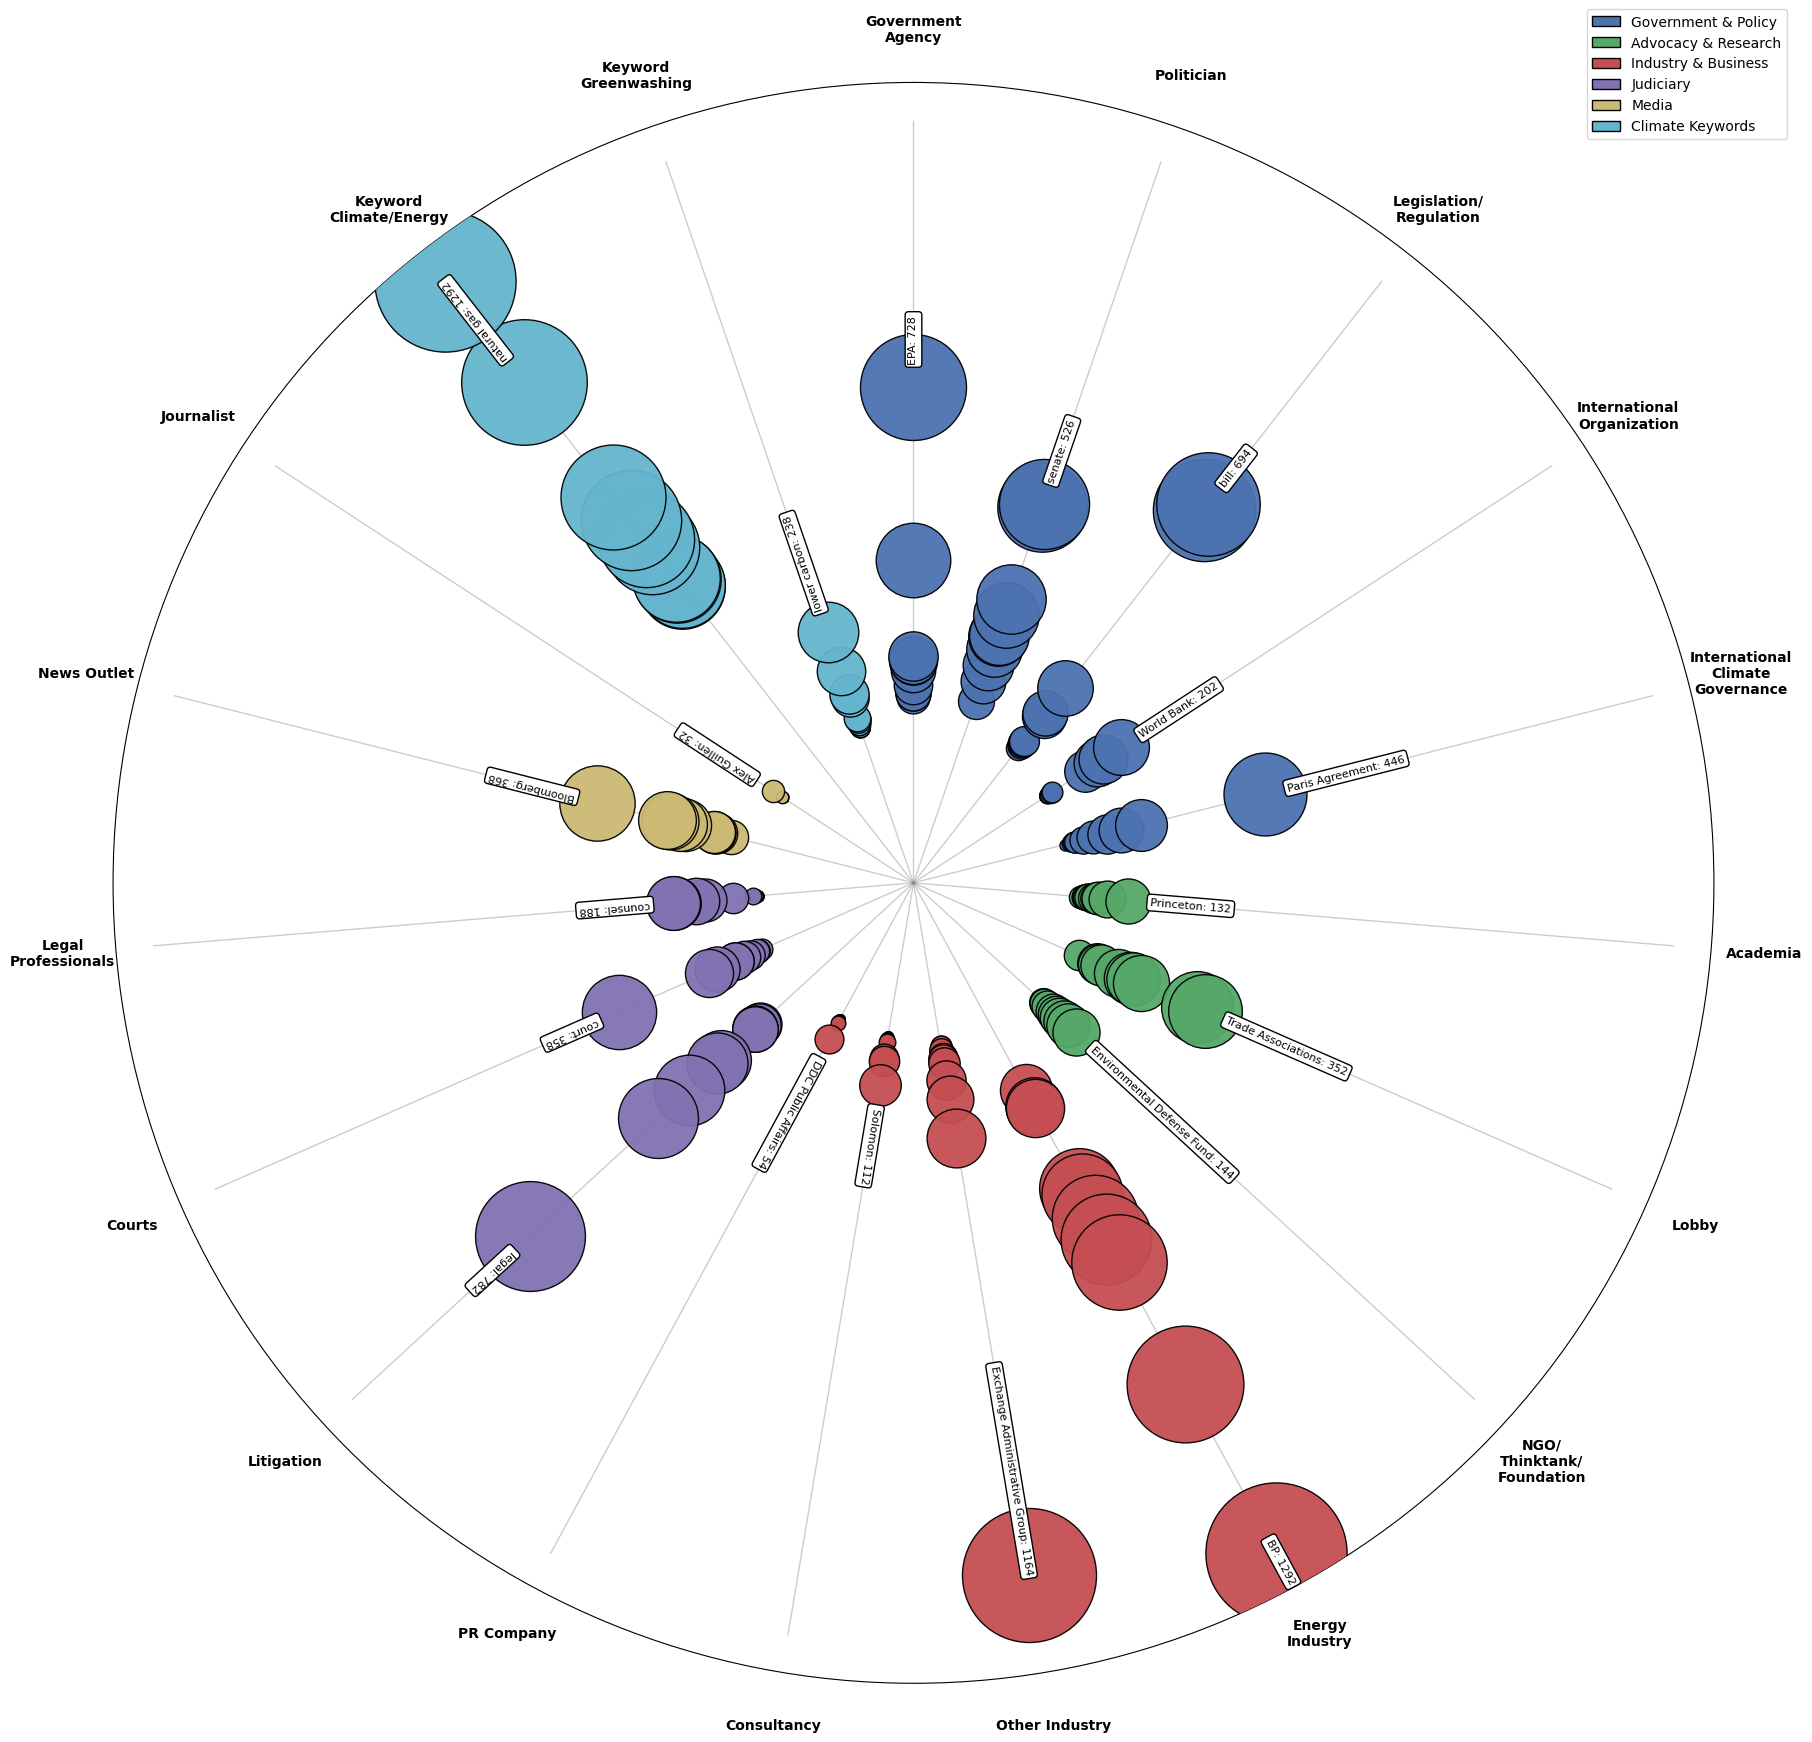

In [35]:

#df_a = pd.read_excel("Final_DatasetA_102725.xlsx") # switch on if you dont want to run the keyword match again and just want to load the already-populated dataset for the hive plot
#df_b = pd.read_excel("Final_DatasetB_031926.xlsx")

# Rename columns to match umbrella_mapping
df_b = df_b.rename(columns={"Legislation": "Legislation/Regulation"})
df_a = df_a.rename(columns={"Legislation": "Legislation/Regulation"})

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import textwrap

# -----------------------------
# SETTINGS
# -----------------------------
group_colors = {
    "Government & Policy": "#4C72B0",
    "Advocacy & Research": "#55A868",
    "Industry & Business": "#C44E52",
    "Judiciary": "#8172B2",
    "Media": "#CCB974",
    "Climate Keywords": "#64B5CD"
}

def wrap_label(text, width=14):
    text = text.replace("_", " ")
    # Allow wrapping at "/" only for words too long to fit on one line
    words = text.split()
    processed = [w.replace("/", "/ ") if len(w) > width and "/" in w else w for w in words]
    return "\n".join(l.rstrip() for l in textwrap.wrap(" ".join(processed), width=width))

# -----------------------------
# PRECOMPUTE CATEGORY

cat_to_group = {
    col: umbrella
    for umbrella, cols in umbrella_mapping.items()
    for col in cols
}

# -----------------------------
# STEP 1: EXTRACT TOP 5
# -----------------------------
categories = {}
frequencies_all = {}

for umbrella, cols in umbrella_mapping.items():
    for col in cols:

        # check BOTH dataframes
        if col not in df_b.columns and col not in df_b.columns:
            continue

        # collect available columns
        series_list = []

        if col in df_b.columns:
            series_list.append(df_b[col])

        if col in df_b.columns:
            series_list.append(df_b[col])

        # combine
        combined_series = pd.concat(series_list, ignore_index=True)

        entities = (
            combined_series
            .dropna()
            .astype(str)
            .str.split(';')
            .explode()
            .str.strip()
        )

        entities = entities[entities != ""]

        counter = Counter(entities)

        top5 = [e for e, _ in counter.most_common(10)]

        categories[col] = top5
        frequencies_all[col] = counter


# -----------------------------
# STEP 2: ORDER CATEGORIES
# -----------------------------
ordered_cats = []
for umbrella, cols in umbrella_mapping.items():
    ordered_cats.extend([c for c in cols if c in categories])

# -----------------------------
# STEP: CAP GLOBAL OUTLIER
# -----------------------------
all_counts = [
    count
    for counter in frequencies_all.values()
    for count in counter.values()
]

unique_counts = sorted(set(all_counts), reverse=True)

# ensure we have at least 2 distinct values
if len(unique_counts) > 1:
    max_val = unique_counts[0]
    second_max_val = unique_counts[1]

    # cap all occurrences of the max
    for counter in frequencies_all.values():
        for key in counter:
            if counter[key] == max_val:
                counter[key] = second_max_val
                
# -----------------------------
# STEP 3: GLOBAL NORMALIZATION
# -----------------------------
global_max = max(
    count
    for counter in frequencies_all.values()
    for count in counter.values()
)

# -----------------------------
# STEP 4: HIVE PLOT PREP
# -----------------------------
N = len(ordered_cats)
theta_axes = np.linspace(0, 2*np.pi, N, endpoint=False)

R_max = 10
plot_data = []

for i, cat in enumerate(ordered_cats):
    angle = theta_axes[i]
    items = categories.get(cat, [])

    if len(items) == 0:
        continue

    freq_counter = frequencies_all[cat]

    # sort by frequency (clean visual gradient)
    sorted_items = sorted(items, key=lambda e: freq_counter[e])

    for item in sorted_items:
        freq = freq_counter[item]

        # GLOBAL scaling (important!)
        r = 2 + (freq / global_max) * (R_max - 2)

        plot_data.append({
            "cat": cat,
            "entity": item,
            "angle": angle,
            "r": r,
            "freq": freq,
            "color": group_colors.get(cat_to_group.get(cat), "gray")
        })


# -----------------------------
# STEP 5: DRAW HIVE PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 18), subplot_kw={'polar': True})

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)

# Draw category axes
for angle in theta_axes:
    ax.plot([angle, angle], [0, R_max], color='gray', lw=1, alpha=0.4)

# Draw entity bubbles
for d in plot_data:
    size = 8 * d["freq"]

    ax.scatter(
        d["angle"],
        d["r"],
        s=size,
        color=d["color"],
        edgecolors='black',
        alpha=0.95,
        zorder=5
    )

# -----------------------------
# 3) Annotate top frequency per category outside the bubble
# -----------------------------

for cat in ordered_cats:
    freq_counter = frequencies_all[cat]
    if not freq_counter:
        continue

    # Top entity
    top_entity, top_freq = freq_counter.most_common(1)[0]

    # Find bubble info
    bubble = next((d for d in plot_data if d["cat"] == cat and d["entity"] == top_entity), None)
    if bubble is None:
        continue

    exception1 = {"Legislation"}
    exception2 = {"Energy Industry"}
    inward_cats = {"Keyword Climate/Energy", "Other Industry"}

    r_label = bubble["r"] + 0.3
    if cat in exception1:
        r_label -= 1.2
    elif cat in exception2:
        r_label -= 0.5

    angle = bubble["angle"]
    rotation = np.degrees(np.pi/2 - angle)

    if cat in inward_cats:
        # Label starts at bubble centre, text extends inward toward origin
        ax.text(
        angle,
        bubble["r"],
        f"{top_entity}: {top_freq}",
        ha='right',
        va='center',
        fontsize=8,
        fontweight='normal',
        color='black',
        rotation=rotation,
        rotation_mode='anchor',
        zorder=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=1.0
        )
        )
    else:
        ax.text(
        angle,
        r_label,
        f"{top_entity}: {top_freq}",
        ha='left',
        va='center',
        fontsize=8,
        fontweight='normal',
        color='black',
        rotation=rotation,
        rotation_mode='anchor',
        zorder=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            linewidth=1.0
        )
        )
   
# -----------------------------
# 4) Draw category labels
# -----------------------------
for i, cat in enumerate(ordered_cats):
    angle = theta_axes[i]
    ax.text(
        angle,
        R_max + 1.2,
        wrap_label(cat),
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold'
    )


# Legend
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor='black', label=grp)
    for grp, color in group_colors.items()
]

legend = plt.legend(handles=legend_handles, loc='upper right', frameon=True, bbox_to_anchor=(1.05, 1.05), bbox_transform=ax.transAxes)
legend.get_frame().set_linewidth(1)

# Clean styling
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# Top 5 entities per category across both df_a and df_b (same data as hive plot)
# Top 5 entities per category across both df_a and df_b (same data as hive plot)
print("Top 5 entities per category (combined df_a + df_b)\n")

for cat in ordered_cats:
    counter = frequencies_all.get(cat)
    if not counter:
        continue
    top5 = counter.most_common(5)
    group = cat_to_group.get(cat, "")
    print(f"{group} > {cat}")
    for entity, freq in top5:
        print(f"  {entity:<45} {freq}")
    print()
for cat in ordered_cats:
    counter = frequencies_all.get(cat)
    if not counter:
        continue
    top5 = counter.most_common(5)
    group = cat_to_group.get(cat, "")
    print(f"{group} > {cat}")
    for entity, freq in top5:
        print(f"  {entity:<45} {freq}")
    print()


Top 5 entities per category (combined df_a + df_b)

Government & Policy > Government Agency
  EPA                                           728
  White House                                   360
  DOE                                           158
  Finance Committee                             150
  Environmental Protection Agency               146

Government & Policy > Politician
  senate                                        526
  Trump                                         518
  republican                                    312
  Trump Administration                          278
  governor                                      232

Government & Policy > Legislation
  bill                                          694
  Legislation                                   678
  Clean Power Plan                              200
  Clean Air Act                                 132
  Energy Act of 2020                            126

Government & Policy > International Organization
  World B

In [22]:
from collections import Counter

def print_top_bottom_entities(df, dataset_name, cols, n=10):
    print("=" * 60)
    print("Dataset:", dataset_name)
    print("=" * 60)
    for cat in cols:
        if cat not in df.columns:
            continue
        # Parse all semicolon-separated entities in the column
        entities = [
            e.strip()
            for cell in df[cat].dropna()
            for e in str(cell).split(";")
            if e.strip()
        ]
        if not entities:
            continue
        counts = Counter(entities).most_common()
        top = counts[:n]
        bottom = counts[-n:] if len(counts) >= n else counts
        print()
        print("--- " + cat + " (" + str(len(counts)) + " unique entities) ---")
        print("  Top " + str(n) + ":")
        for entity, freq in top:
            print("    " + entity + ": " + str(freq))
        if len(counts) > n:
            print("  Bottom " + str(min(n, len(counts))) + ":")
            for entity, freq in bottom:
                print("    " + entity + ": " + str(freq))

print_top_bottom_entities(df_a, "Dataset A", cols_to_clear)
print()
print_top_bottom_entities(df_b, "Dataset B", cols_to_clear)

Dataset: Dataset A

--- Academia (27 unique entities) ---
  Top 10:
    MIT: 27
    Columbia: 12
    academic: 10
    Journal: 7
    Columbia University: 6
    Princeton: 6
    Jason Bordoff: 5
    Harvard: 4
    CMI: 4
    Oxford: 4
  Bottom 10:
    Princeton University: 1
    Tufts: 1
    dean: 1
    Columbia Journalism School: 1
    University of Michigan: 1
    Imperial College London: 1
    university: 1
    University of Western Australia: 1
    Australian National University: 1
    LSU: 1

--- Consultancy (1 unique entities) ---
  Top 10:
    1776.0: 1

--- Courts (16 unique entities) ---
  Top 10:
    trial: 22
    hearing: 8
    jurisdiction: 7
    precedent: 6
    jury: 4
    The Hague: 4
    court: 3
    Supreme Court: 2
    justice: 2
    decree: 1
  Bottom 10:
    court: 3
    Supreme Court: 2
    justice: 2
    decree: 1
    judgement: 1
    ruling: 1
    appellate: 1
    district court: 1
    Circuit Court of Appeals: 1
    U.S. Court of Appeals: 1

--- Energy Industry (